In [1]:
import pandas as pd
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


In [2]:
# Load dataset
df = pd.read_csv("dataset_2191_sleep.csv")

# Replace '?' with NaN and convert necessary columns
columns_to_convert = ['max_life_span', 'gestation_time', 'total_sleep']
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop
df.dropna(inplace=True)

df.head()


,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645.0,3,5,3,3.3
1,1.000,6.6,4.5,42.0,3,1,3,8.3
2,3.385,44.5,14.0,60.0,1,1,1,12.5
4,2547.000,4603.0,69.0,624.0,3,5,4,3.9
5,10.550,179.5,27.0,180.0,4,4,4,9.8


In [3]:
# Summary statistics
df.describe()


,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.00000
mean,224.363078,317.502353,20.147059,142.068627,2.843137,2.450980,2.627451,10.34902
std,988.465573,1018.888421,19.034982,142.460381,1.488255,1.578781,1.427736,4.67946
min,0.005000,0.140000,2.000000,12.000000,1.000000,1.000000,1.000000,2.60000
25%,0.615000,4.500000,6.250000,42.000000,2.000000,1.000000,1.000000,7.30000
50%,3.385000,21.000000,14.000000,100.000000,3.000000,2.000000,2.000000,10.30000
75%,44.245000,172.000000,27.500000,205.000000,4.000000,4.000000,4.000000,13.20000
max,6654.000000,5712.000000,100.000000,645.000000,5.000000,5.000000,5.000000,19.90000


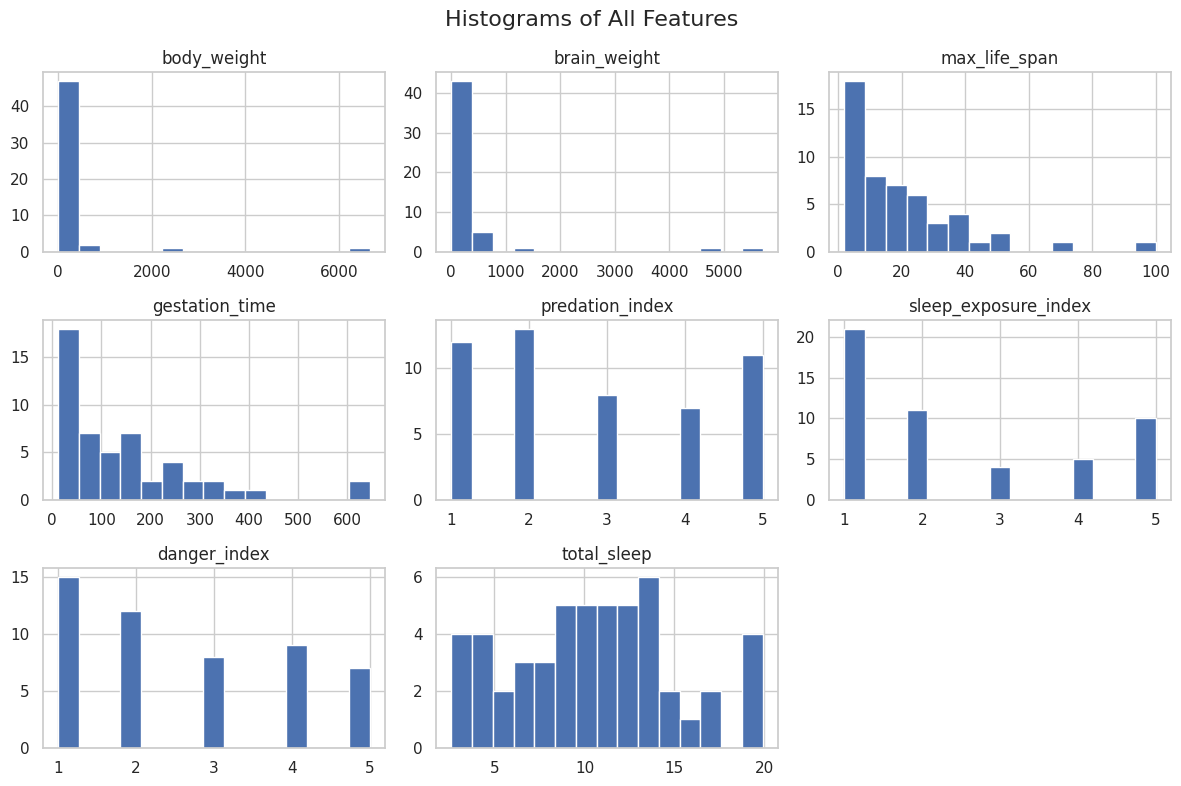

In [4]:
# Histograms
df.hist(bins=15, figsize=(12, 8), layout=(3, 3))
plt.suptitle("Histograms of All Features", fontsize=16)
plt.tight_layout()
plt.show()


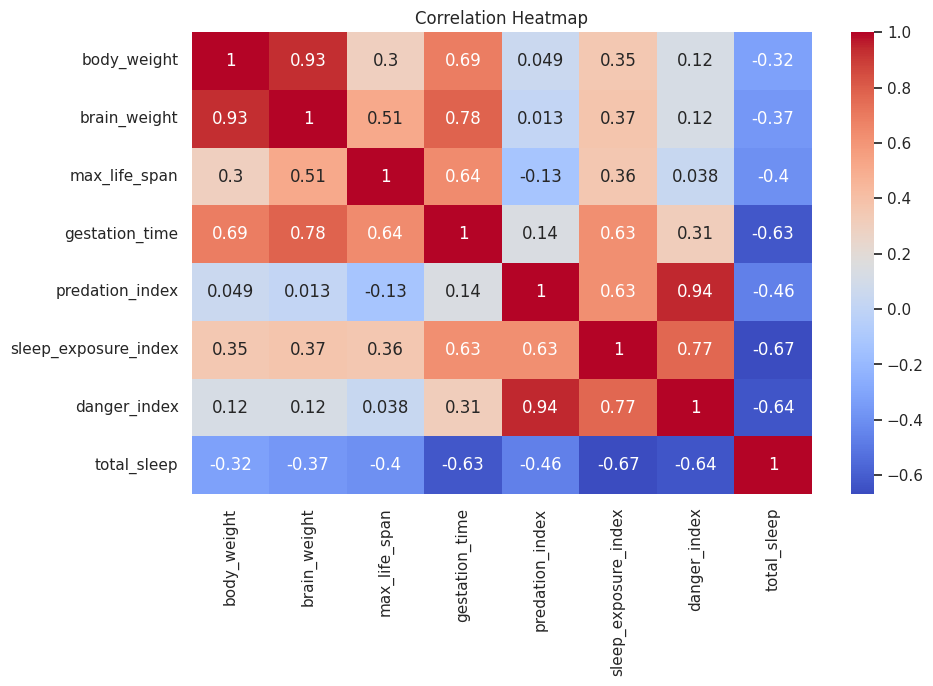

In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


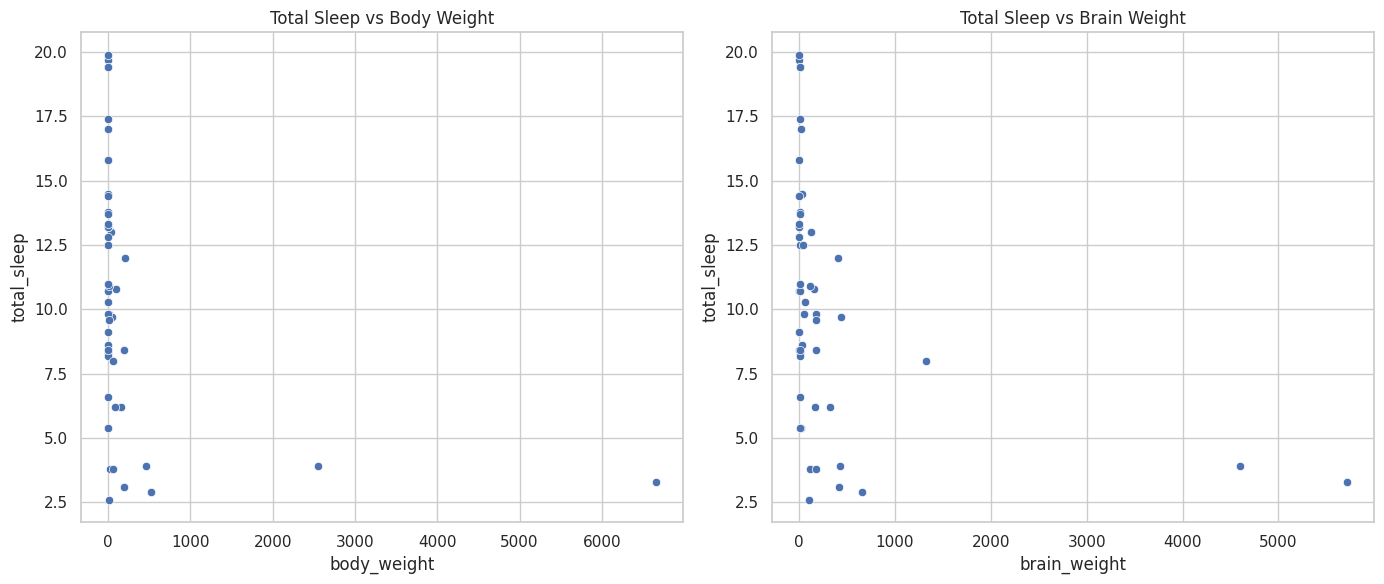

In [7]:
# Scatter plots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=df, x='body_weight', y='total_sleep', ax=axs[0])
axs[0].set_title('Total Sleep vs Body Weight')

sns.scatterplot(data=df, x='brain_weight', y='total_sleep', ax=axs[1])
axs[1].set_title('Total Sleep vs Brain Weight')

plt.tight_layout()
plt.show()


/tmp/ipython-input-8-3810751475.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_sleep_by_danger, x='danger_index', y='total_sleep', palette='viridis')


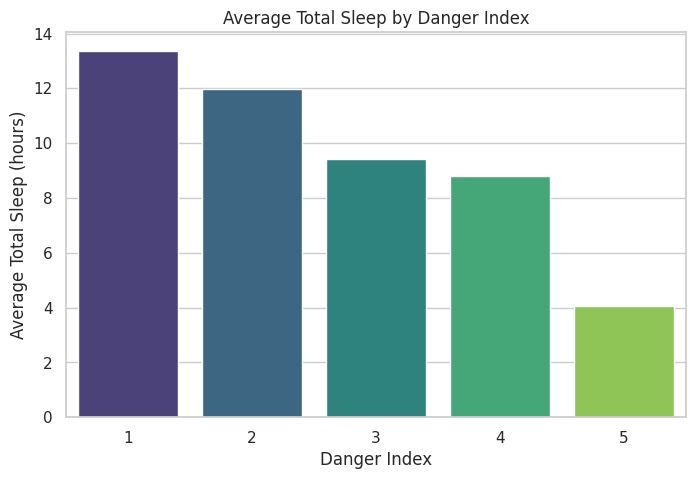

In [8]:
# Average sleep by danger index
avg_sleep_by_danger = df.groupby('danger_index')['total_sleep'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_sleep_by_danger, x='danger_index', y='total_sleep', palette='viridis')
plt.title("Average Total Sleep by Danger Index")
plt.ylabel("Average Total Sleep (hours)")
plt.xlabel("Danger Index")
plt.show()


In [9]:
# Drop unnecessary columns
df_cleaned = df.drop(columns=['UserId', 'Start', 'End'], errors='ignore')
df_cleaned.head()


,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645.0,3,5,3,3.3
1,1.000,6.6,4.5,42.0,3,1,3,8.3
2,3.385,44.5,14.0,60.0,1,1,1,12.5
4,2547.000,4603.0,69.0,624.0,3,5,4,3.9
5,10.550,179.5,27.0,180.0,4,4,4,9.8


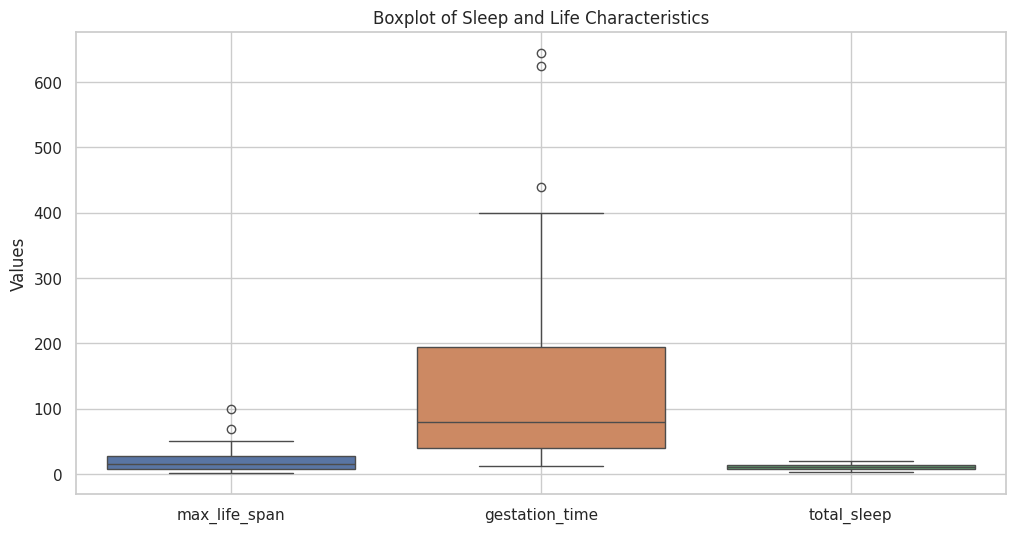

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("dataset_2191_sleep.csv")

# Replace '?' with NaN and convert specific columns to numeric
columns_to_convert = ['max_life_span', 'gestation_time', 'total_sleep']
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values with median
df[columns_to_convert] = df[columns_to_convert].fillna(df[columns_to_convert].median())

# Boxplot visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[columns_to_convert])
plt.title("Boxplot of Sleep and Life Characteristics")
plt.ylabel("Values")
plt.grid(True)
plt.show()
